# Renaming GeoPackage Layers

In [1]:
from pathlib import Path

import fiona
import geopandas as gpd
import matplotlib.pyplot as plt

## GeoPackage Inspection

In [2]:
data_folder = Path('../../data')
nederland = Path('../../data/nederland_admin_areas_old.gpkg')

In [3]:
old_layers = fiona.listlayers(nederland)
old_layers

['gemeentegebied', 'landgebied', 'provinciegebied']

## Renaming the Layers

In [4]:
new_layers = ['cities', 'country', 'provinces']
new_layers

['cities', 'country', 'provinces']

In [5]:
new_path = Path(f'{data_folder}/nederland_admin_areas_new.gpkg')

for new, old in zip(new_layers, old_layers):
    gdf = gpd.read_file(nederland, layer=old)
    gdf.to_file(new_path, layer=new, driver='GPKG')

renamed_layers = fiona.listlayers(new_path)
renamed_layers

['cities', 'country', 'provinces']

## Visualising All Layers

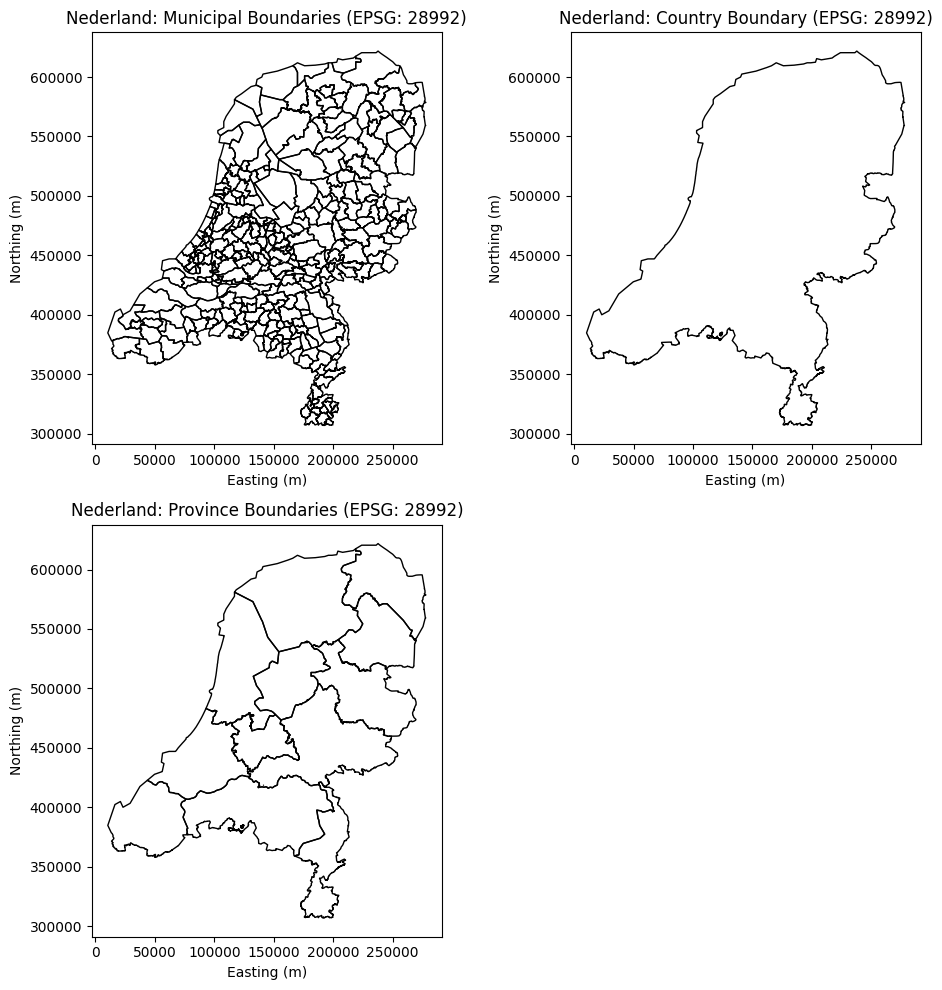

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,10))
axs = axes.flatten()
ax_titles = ['Nederland: Municipal Boundaries', 'Nederland: Country Boundary', 'Nederland: Province Boundaries']

for ax, layer, title in zip(axs, renamed_layers, ax_titles):
    gdf = gpd.read_file(new_path, layer=layer)
    gdf.plot(ax=ax, color='none')

    ax.set_title(f'{title} (EPSG: 28992)')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    
for ax in axs[len(ax_titles):]:
    fig.delaxes(ax)
    
plt.tight_layout()
plt.show()